In [21]:
import matplotlib.pyplot as plt
import numpy as np
import portion as P

from dataclasses import dataclass
from portion import Interval

# Problem statement

We have a variable **X** over a group of people. Any distribution or population size will do, but let's just assume it's a normal variable over a population of 800.

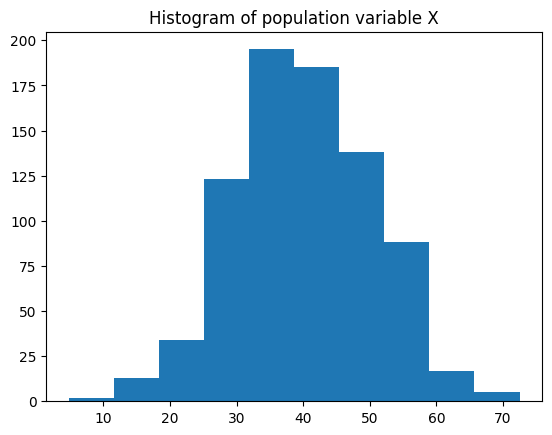

In [56]:
data = np.random.normal(loc=40, scale=10, size=800)
plt.hist(data)
plt.title('Histogram of population variable X')
plt.show()

A _range query_ is a question of the form "For how many people is **X** between _a_ and _b_?" We can answer a range query by counting the number of people whose **X** is in that range.

In [57]:
def query_v1(data: list[float], interval: Interval) -> int:
    return sum(interval.contains(d) for d in data)

i1 = P.closedopen(0, 10)
i2 = P.closedopen(30, 50)
print(f'{query_v1(data, i1)} people in [{i1.lower}, {i1.upper})')
print(f'{query_v1(data, i2)} people in [{i2.lower}, {i2.upper})')

2 people in [0, 10)
523 people in [30, 50)


# Applying differential privacy

However, let's assume we should consider the data to be _private_. Then an attacker could use `query_v1` to zero in on actual values of **X** for individuals in our population, so we can't expose `query_v1`. But we could apply differential privacy, and declare that it is okay to release counts, provided we add some noise to them. We decide on a _privacy budget_ epsilon, which acts as a limited allowance of truth we can safely release.

In [59]:
def make_noise(epsilon: float) -> float:
    return np.random.laplace(scale=1 / epsilon)

def query_v2(data: list[float], interval: Interval, epsilon: float) -> int:
    return int(query_v1(data, interval) + make_noise(epsilon))

epsilon = 1.0 # To see a bigger difference, try something smaller

print(f'About {query_v2(data, i1, epsilon)} people in [{i1.lower}, {i1.upper})')
print(f'About {query_v2(data, i2, epsilon)} people in [{i2.lower}, {i2.upper})')

About 1 people in [0, 10)
About 522 people in [30, 50)


But `query_v2` has problems of its own: namely, the privacy impact of whatever information we release through it has to be considered in aggregate. In other words, if we run `query_v2` twice then we exceed our allotted privacy budget of epsilon. If we wanted to run `n` queries, we could work around this by running `query_v2` with `epsilon / n`, but this comes with the disadvantages that the accuracy could be lower for large `n`, and afterwards we can no longer answer more queries safely.

# Scaling to large numbers of queries

A better way is to construct pre-noised _segments_ of data. Each segment tells us the count of people whose **X** falls within a certain interval. It also importantly includes noise, which we must add to the count before reporting it. By intelligently combining segments together, we can approximate the answer to any range query; and by effectively introducing all the necessary noise up-front when we create our segments, we avoid making additional revelations about our underlying data every time we answer another query.

In [45]:
@dataclass
class Segment:
    interval: Interval
    people: int = 0
    noise: float = 0.0

We create the segments in a series of _levels_. The first level is just one segment, and it has the widest interval for **X** that we choose to support, in its entirety. The second level has two segments, the interval from the first level being split in half. The third level has four segments, and so forth. We stop creating levels when the intervals reach the minimum level of _granularity_ that we choose to support.

**Future enhancement:** We may find advantage in splitting the intervals into more than two parts. However the number of segments on one level must always be a multiple of the number of segments on the level above.

In [46]:
def make_segments(interval: Interval, granularity: float) -> list[Segment]:
    result = []
    segments = 1
    length = np.abs(interval.upper - interval.lower)

    while length >= granularity:
        lower = interval.lower
        upper = lower + length

        while upper <= interval.upper:
            result.append(Segment(P.closedopen(lower, upper)))
            lower += length
            upper += length

        segments *= 2
        length /= 2

    return result

We next put the people from our data set into their appropriate segments based on their **X** values. If we set our intervals correctly, each person should fit in exactly one segment on each level - a property that will help us stretch epsilon as far as possible.

In [47]:
def apply_segment_people(segments: list[Segment], data: list[float]):
    for d in data:
        for s in segments:
            if s.interval.contains(d):
                s.people += 1

We next set the noise for the segments, based on an epsilon of our choosing. Because each individual appears in exactly one segment per level, we do not need to divide epsilon by the number of segments we have created: rather we need only divide epsilon by the number of levels we have created. In the language of differential privacy, we have _sequential composition_ between levels (each level requires a dedicated piece of our epsilon), but _parallel composition_ within a level (each segment can share the same piece of epsilon).

**Future enhancement:** We assume here that the number of segments on each level consistently doubles. If we were to break apart the segments into smaller pieces differently, this logic would break.

In [48]:
def apply_segment_noise(segments: list[Segment], epsilon: float):
    epsilon_share = epsilon / np.log2(len(segments))
    for s in segments:
        s.noise = make_noise(epsilon_share)

# Range query algorithms

Our data appears to range from about 0 to 80. We will be satisfied to discard any data outside that range; but better would be to _clip_ the data, bringing every **X** < 0 up to 0, and every **X** > 80 down to 80. We choose a granularity of 1, for demonstration purposes. Putting it all together, we have a nice list of segments to work with.

In [62]:
segments = make_segments(P.closedopen(0, 80), 1.0)
apply_segment_people(segments, data)
apply_segment_noise(segments, epsilon)

segments[0:4]

[Segment(interval=[0,80), people=800, noise=-3.5035200243516647),
 Segment(interval=[0,40.0), people=414, noise=-0.808097436150928),
 Segment(interval=[40.0,80.0), people=386, noise=3.7506932930889083),
 Segment(interval=[0,20.0), people=23, noise=-4.378914071382114)]

Now the goal is to take a range query, and figure out what segments we can combine together to answer it. The fewer segments we use, the less noisy our answer will usually be. We test two query algorithms. The algorithm finds segments that cover the desired range with as little underextension at the endpoints as possible.

**Future enhancement:** The algorithms rely on the segments being ordered by level, from largest to smallest. We may wish to use a richer data structure than a list of segments. Further, we may wish to add customization around whether the algorithms overextend or underextend.

**Future enhancement:** A better algorithm might consider that overextending and then _subtracting off_ people can sometimes answer the query using fewer segments.

In [70]:
def query_v3(segments: list[Segment], interval: Interval):
    result = []
    for s in segments:
        if s.interval in interval:
            result.append(s)
            for leftover in interval - s.interval:
                result += query_v3(segments, leftover)
            break

    return result

answer = query_v3(segments, i2)
answer

[Segment(interval=[30.0,40.0), people=287, noise=4.5427128112444946),
 Segment(interval=[40.0,50.0), people=236, noise=-3.512041693482979)]

In [72]:
def combine_segments(segments: list[Segment]) -> int:
    return int(sum([s.people + s.noise for s in segments]))

combine_segments(answer)

524